In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Noise function
def add_gaussian_noise(image, noise_factor=0.4):
    noise = torch.randn_like(image) * noise_factor
    return torch.clamp(image + noise, 0., 1.)

# Load the TEST dataset (train=False — data the models have NEVER seen)
transform = transforms.Compose([transforms.ToTensor()])
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print("Test Data loaded successfully!")
print(f"Total test images: {len(test_dataset)}")

100.0%
100.0%
100.0%
100.0%

Test Data loaded successfully!
Total test images: 10000


In [2]:
# 1. The Healer Blueprint
class DenoisingVAE(nn.Module):
    def __init__(self):
        super(DenoisingVAE, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.fc_mu = nn.Linear(64 * 7 * 7, 20)
        self.fc_logvar = nn.Linear(64 * 7 * 7, 20)
        self.fc_decode = nn.Linear(20, 64 * 7 * 7)
        self.dec_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(-1, 64 * 7 * 7)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        x = F.relu(self.fc_decode(z))
        x = x.view(-1, 64, 7, 7)
        x = F.relu(self.dec_conv1(x))
        return torch.sigmoid(self.dec_conv2(x)), mu, logvar

# 2. The Expert Blueprint
class ExpertCNN(nn.Module):
    def __init__(self):
        super(ExpertCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

print("Both blueprints defined!")

Both blueprints defined!


In [5]:
import os

print("Current location:", os.getcwd())
print()

# Search entire project for any .pth files
print("Searching for .pth files...")
found = False
for root, dirs, files in os.walk('..'):
    for file in files:
        if file.endswith('.pth'):
            print(f"  FOUND: {os.path.join(root, file)}")
            found = True

if not found:
    print("  NO .pth files found anywhere!")
    print()
    print("You need to go back to your Healer and Expert notebooks and save them first.")

Current location: C:\Users\Rushikesh\OneDrive\CODES\SelfHealingNN\notebooks

Searching for .pth files...
  FOUND: ..\notebooks\models\expert_cnn.pth
  FOUND: ..\venv\Lib\site-packages\distutils-precedence.pth


In [6]:
healer = DenoisingVAE()
expert = ExpertCNN()

healer.load_state_dict(torch.load('../models/healer_vae.pth', weights_only=True))
expert.load_state_dict(torch.load('../models/expert_cnn.pth', weights_only=True))

healer.eval()
expert.eval()

print("Brains loaded and ready for testing!")

Brains loaded and ready for testing!


In [7]:
correct_clean  = 0
correct_noisy  = 0
correct_healed = 0
total          = 0

print("Running pipeline test... please wait.")

with torch.no_grad():
    for clean_images, labels in test_loader:

        # 1. Create noisy images
        noisy_images = add_gaussian_noise(clean_images, noise_factor=0.5)

        # 2. Heal the noisy images
        healed_images, _, _ = healer(noisy_images)

        # 3. Get Expert predictions for all 3 scenarios
        pred_clean  = expert(clean_images).argmax(dim=1)
        pred_noisy  = expert(noisy_images).argmax(dim=1)
        pred_healed = expert(healed_images).argmax(dim=1)

        # 4. Tally the scores
        total          += labels.size(0)
        correct_clean  += (pred_clean  == labels).sum().item()
        correct_noisy  += (pred_noisy  == labels).sum().item()
        correct_healed += (pred_healed == labels).sum().item()

acc_clean  = 100 * correct_clean  / total
acc_noisy  = 100 * correct_noisy  / total
acc_healed = 100 * correct_healed / total

print("\n========== FINAL RESULTS ==========")
print(f"1. Baseline  (Clean Data):        {acc_clean:.2f}%")
print(f"2. Disaster  (Noisy Data):        {acc_noisy:.2f}%")
print(f"3. Self-Healing (Noisy→Healer):   {acc_healed:.2f}%")
print("====================================")
print(f"Accuracy recovered by Healer:     +{acc_healed - acc_noisy:.2f}%")

Running pipeline test... please wait.

========== FINAL RESULTS ==========
1. Baseline  (Clean Data):        98.91%
2. Disaster  (Noisy Data):        78.74%
3. Self-Healing (Noisy→Healer):   91.31%
Accuracy recovered by Healer:     +12.57%


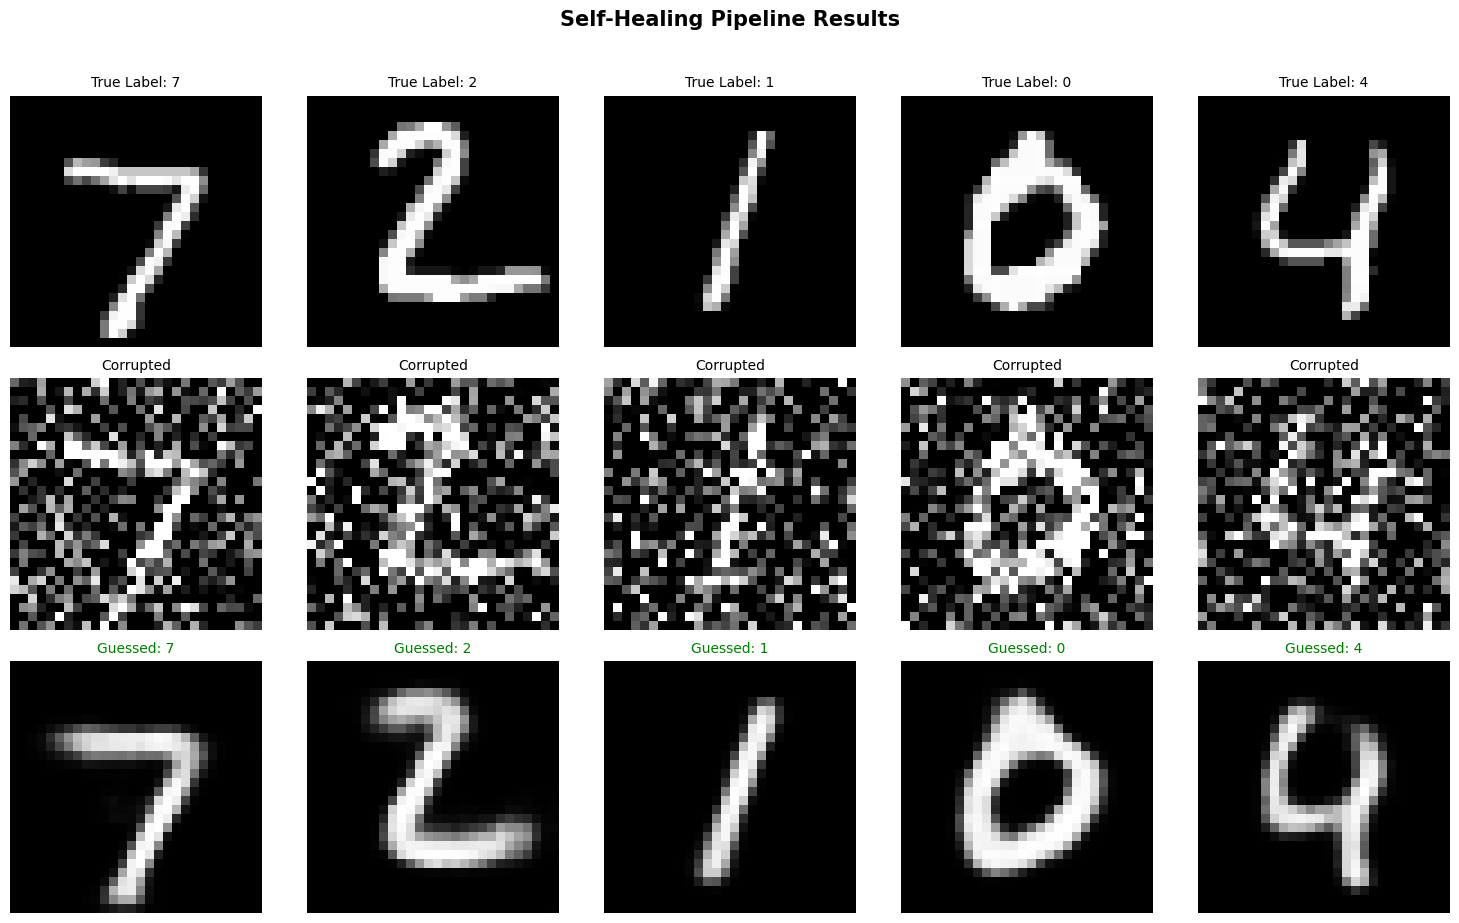


Per-image results:
  Image 1: True=7  Guessed=7  CORRECT
  Image 2: True=2  Guessed=2  CORRECT
  Image 3: True=1  Guessed=1  CORRECT
  Image 4: True=0  Guessed=0  CORRECT
  Image 5: True=4  Guessed=4  CORRECT


In [9]:
# Grab one batch of test data
clean_imgs, labels = next(iter(test_loader))
noisy_imgs = add_gaussian_noise(clean_imgs, noise_factor=0.5)

with torch.no_grad():
    healed_imgs, _, _ = healer(noisy_imgs)
    guesses = expert(healed_imgs).argmax(dim=1)

# Plot first 5 examples across 3 rows
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

row_titles = ['Clean Input', 'Noisy Input', 'Healed Output']
for row, title in enumerate(row_titles):
    axes[row, 0].set_ylabel(title, fontsize=13, fontweight='bold')

for i in range(5):
    axes[0, i].imshow(clean_imgs[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f"True Label: {labels[i].item()}", fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(noisy_imgs[i].squeeze(), cmap='gray')
    axes[1, i].set_title("Corrupted", fontsize=10)
    axes[1, i].axis('off')

    axes[2, i].imshow(healed_imgs[i].squeeze(), cmap='gray')
    color = 'green' if guesses[i].item() == labels[i].item() else 'red'
    axes[2, i].set_title(f"Guessed: {guesses[i].item()}", color=color, fontsize=10)
    axes[2, i].axis('off')

plt.suptitle('Self-Healing Pipeline Results', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print per-image verdict
print("\nPer-image results:")
for i in range(5):
    status = "CORRECT" if guesses[i].item() == labels[i].item() else "WRONG"
    print(f"  Image {i+1}: True={labels[i].item()}  Guessed={guesses[i].item()}  {status}")